<a href="https://colab.research.google.com/github/jaison-leonardo/house-predictor-back/blob/main/Big_data_An%C3%A1lisis_de_Ventas_de_Casas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# Librerías y datos

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    classification_report,
    mean_squared_error,
    r2_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive/')

path = '/content/drive/MyDrive/Colab Notebooks/Big data files/ventas de casas/'
df = pd.read_csv(path + 'train.csv')

print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [41]:
# Limpieza y transformación

df["SalePrice_log"] = np.log1p(df["SalePrice"])

# Eliminamos ID (no aporta información predictiva)
df.drop("Id", axis=1, inplace=True)

df.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247699
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109016
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317171
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849405
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429220


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [43]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,SalePrice_log
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,12.024057
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.399449
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,10.460271
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,11.775105
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,12.001512
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,12.273736
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,13.534474


In [44]:
print('Este dataset cuenta con', df.shape[0], 'filas y', df.shape[1], 'columnas.')
print('Caracteristicas del dataset: ', list(df.columns))

Este dataset cuenta con 1460 filas y 81 columnas.
Caracteristicas del dataset:  ['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenP

In [45]:
# Separamos variables
X = df.drop(["SalePrice", "SalePrice_log"], axis=1)
y_reg = df["SalePrice_log"]

# Para clasificación creamos categorías balanceadas
df["PriceCategory"] = pd.qcut(df["SalePrice"], q=3, labels=["Low", "Mid", "High"])
y_clf = df["PriceCategory"]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

Distribución del precio

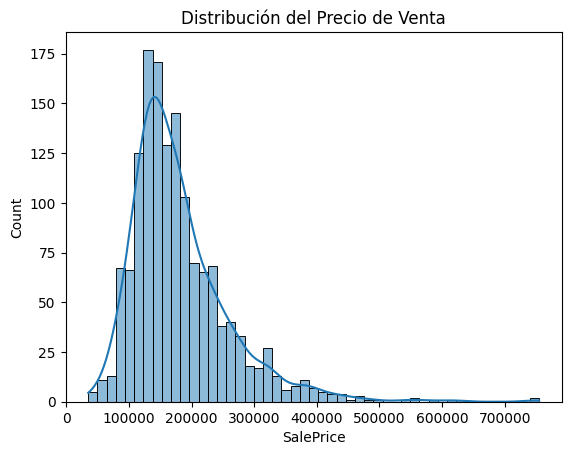

In [46]:
plt.figure()
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribución del Precio de Venta")
plt.show()

In [5]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
nulls.head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [47]:
# Preprocesamiento

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [49]:
# KNN Model
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3,5,7,9,11],
    "model__weights": ["uniform","distance"]
}

grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train, y_clf_train)

print("Best params:", grid_knn.best_params_)
print("CV F1:", grid_knn.best_score_)

# Predicción
y_pred_knn = grid_knn.predict(X_test)

print(classification_report(y_clf_test, y_pred_knn))

Best params: {'model__n_neighbors': 11, 'model__weights': 'distance'}
CV F1: 0.7863633918726787
              precision    recall  f1-score   support

        High       0.88      0.83      0.85        94
         Low       0.80      0.95      0.87       110
         Mid       0.74      0.61      0.67        88

    accuracy                           0.81       292
   macro avg       0.81      0.80      0.80       292
weighted avg       0.81      0.81      0.80       292



In [50]:
# Regresión líneal
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Validación cruzada
cv_scores = cross_val_score(
    linear_pipeline,
    X_train,
    y_reg_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV R2 mean:", cv_scores.mean())
print("CV R2 std:", cv_scores.std())

# Entrenamiento final
linear_pipeline.fit(X_train, y_reg_train)

# Evaluación en test
y_pred_linear = linear_pipeline.predict(X_test)

mse_linear = mean_squared_error(y_reg_test, y_pred_linear)
r2_linear = r2_score(y_reg_test, y_pred_linear)

print("Test MSE:", mse_linear)
print("Test R2:", r2_linear)

CV R2 mean: 0.8094597245292846
CV R2 std: 0.03886009467833877
Test MSE: 0.016406144842491047
Test R2: 0.9120837150773479


Regresión líneal con ridge y lasso

In [63]:
# Ridge con hiperparametros (Optimizado)
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": np.logspace(-3, 3, 20)
}

grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_reg_train)

print("Best alpha:", grid_ridge.best_params_)
print("CV R2:", grid_ridge.best_score_)

# Evaluación Ridge
print("Evaluación Ridge")
y_pred_ridge = grid_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print("Test MSE:", mse_ridge)
print("Test R2:", r2_ridge)

Best alpha: {'model__alpha': np.float64(26.366508987303554)}
CV R2: 0.8606976101422458
Evaluación Ridge
Test MSE: 0.019017345633052622
Test R2: 0.8980909657204911


In [65]:
# Lasso con hiperparametros (Optimizado)

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

param_grid_lasso = {
    "model__alpha": np.logspace(-4, 1, 20)
}

grid_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_reg_train)

print("Best alpha:", grid_lasso.best_params_)
print("CV R2:", grid_lasso.best_score_)

# Evaluación Lasso
print("Evaluación Lasso")
y_pred_lasso = grid_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_reg_test, y_pred_lasso)
r2_lasso = r2_score(y_reg_test, y_pred_lasso)

print("Test MSE:", mse_lasso)
print("Test R2:", r2_lasso)

Best alpha: {'model__alpha': np.float64(0.0006158482110660267)}
CV R2: 0.8622666845040179
Evaluación Lasso
Test MSE: 0.01712533484068038
Test R2: 0.9082297619761552


Arbol de decisión con hiperparametros (Optimizado)

In [66]:
# Regressor
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

param_grid_tree = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10]
}

grid_tree = GridSearchCV(
    tree_pipeline,
    param_grid_tree,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_tree.fit(X_train, y_reg_train)

print("Best params:", grid_tree.best_params_)
print("CV R2:", grid_tree.best_score_)

# Evaluación DecisionTreeRegressor
print("Evaluación DecisionTreeRegressor")
y_pred_tree_reg = grid_tree.predict(X_test)

mse_tree_reg = mean_squared_error(y_reg_test, y_pred_tree_reg)
r2_tree_reg = r2_score(y_reg_test, y_pred_tree_reg)

print("Test MSE:", mse_tree_reg)
print("Test R2:", r2_tree_reg)

Best params: {'model__max_depth': 5, 'model__min_samples_split': 5}
CV R2: 0.7316259815663263
Evaluación DecisionTreeRegressor
Test MSE: 0.04028724364974745
Test R2: 0.7841110860921965


In [69]:
# Classifier

tree_clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid_tree_clf = {
    "model__max_depth": [5,10,20,None],
    "model__min_samples_split": [2,5,10]
}

grid_tree_clf = GridSearchCV(
    tree_clf_pipeline,
    param_grid_tree_clf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_tree_clf.fit(X_train, y_clf_train)

print("Best params:", grid_tree_clf.best_params_)
print("CV F1:", grid_tree_clf.best_score_)

# Evaluación DecisionTreeClassifier
print("Evaluación DecisionTreeClassifier")
y_pred_tree_clf = grid_tree_clf.predict(X_test)

print(classification_report(y_clf_test, y_pred_tree_clf))

print("Confusion Matrix:")
print(confusion_matrix(y_clf_test, y_pred_tree_clf))

Best params: {'model__max_depth': 10, 'model__min_samples_split': 10}
CV F1: 0.7613893178224374
Evaluación DecisionTreeClassifier
              precision    recall  f1-score   support

        High       0.84      0.83      0.83        94
         Low       0.81      0.76      0.79       110
         Mid       0.58      0.62      0.60        88

    accuracy                           0.74       292
   macro avg       0.74      0.74      0.74       292
weighted avg       0.75      0.74      0.75       292

Confusion Matrix:
[[78  1 15]
 [ 1 84 25]
 [14 19 55]]


Real vs Predicho

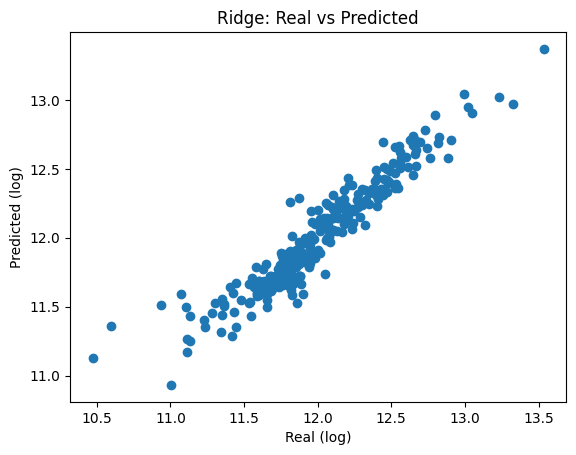

In [56]:
plt.figure()
plt.scatter(y_reg_test, y_pred_ridge)
plt.xlabel("Real (log)")
plt.ylabel("Predicted (log)")
plt.title("Ridge: Real vs Predicho")
plt.show()

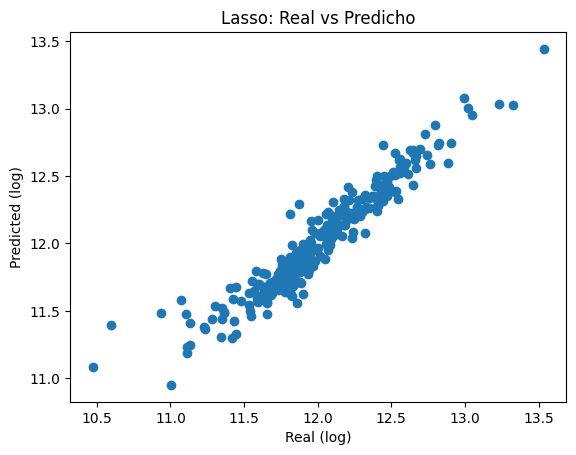

In [59]:
plt.figure()
plt.scatter(y_reg_test, y_pred_lasso)
plt.xlabel("Real (log)")
plt.ylabel("Predicted (log)")
plt.title("Lasso: Real vs Predicho")
plt.show()

Comparación final Regressor

In [70]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Tree"],
    "R2": [
        r2_linear,
        r2_ridge,
        r2_lasso,
        r2_tree_reg
    ]
})

results.sort_values("R2", ascending=False)

,Model,R2
0,Linear,0.912084
2,Lasso,0.908230
1,Ridge,0.898091
3,Tree,0.784111


Comparación final Classifier

In [71]:
# Métricas knn

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_knn = grid_knn.predict(X_test)

acc_knn = accuracy_score(y_clf_test, y_pred_knn)
f1_knn = f1_score(y_clf_test, y_pred_knn, average="macro")
prec_knn = precision_score(y_clf_test, y_pred_knn, average="macro")
rec_knn = recall_score(y_clf_test, y_pred_knn, average="macro")

# Métricas decision tree
y_pred_tree = grid_tree_clf.predict(X_test)

acc_tree = accuracy_score(y_clf_test, y_pred_tree)
f1_tree = f1_score(y_clf_test, y_pred_tree, average="macro")
prec_tree = precision_score(y_clf_test, y_pred_tree, average="macro")
rec_tree = recall_score(y_clf_test, y_pred_tree, average="macro")

results_clf = pd.DataFrame({
    "Model": ["KNN", "DecisionTree"],
    "Accuracy": [acc_knn, acc_tree],
    "F1_macro": [f1_knn, f1_tree],
    "Precision_macro": [prec_knn, prec_tree],
    "Recall_macro": [rec_knn, rec_tree]
})

results_clf.sort_values("F1_macro", ascending=False)

,Model,Accuracy,F1_macro,Precision_macro,Recall_macro
0,KNN,0.808219,0.796644,0.805377,0.796293
1,DecisionTree,0.743151,0.740121,0.741783,0.739475


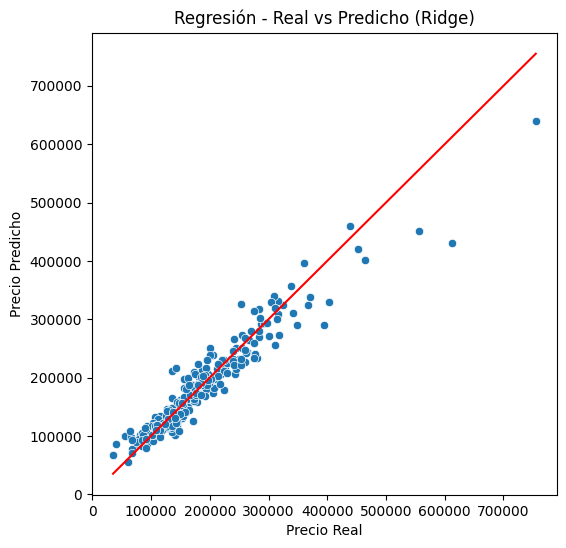

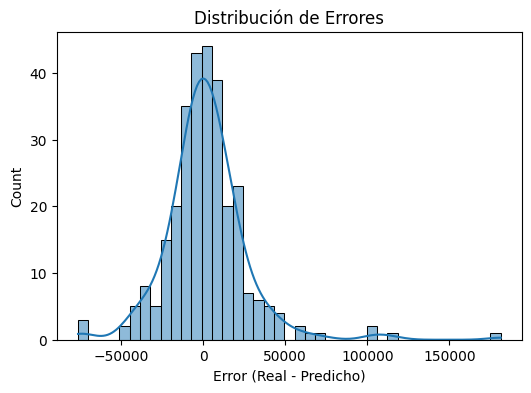

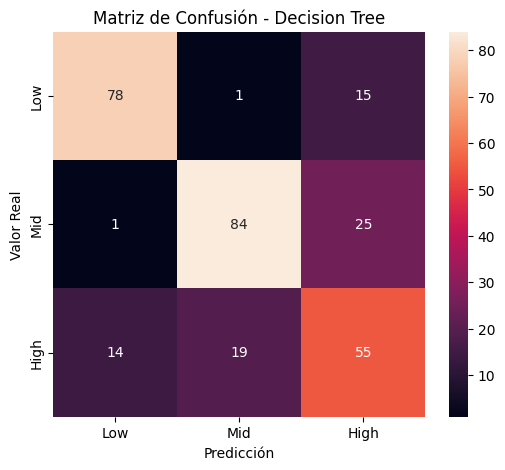

In [74]:
# Resultados
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Regresión - Real vs Predicho

# Convertimos de log a escala real
y_test_real = np.expm1(y_reg_test)
y_pred_real = np.expm1(y_pred_ridge)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_real, y=y_pred_real)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         color="red")
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión - Real vs Predicho (Ridge)")
plt.show()

# Regresión - Distribución de errores

residuals = y_test_real - y_pred_real

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribución de Errores")
plt.xlabel("Error (Real - Predicho)")
plt.show()

# Clasificación - Matriz de Confusión

cm = confusion_matrix(y_clf_test, y_pred_tree)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Low","Mid","High"],
            yticklabels=["Low","Mid","High"])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Decision Tree")
plt.show()